In [21]:
# upload dataset
# Group1: https://www.kaggle.com/datasets/mohithsairamreddy/salary-data
# Group2: https://www.kaggle.com/datasets/jaderz/hospital-beds-management?select=services_weekly.csv
# Group3: https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset
# Group4: https://www.kaggle.com/datasets/jocelyndumlao/inclusive-economics-growth-determinants
# Group5: https://www.kaggle.com/datasets/kbrakssa/students-grading-dataset




In [61]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats

In [62]:
from pathlib import Path

# Path to your CSV file
file_path = Path("data") / "Students_Grading_Dataset.csv"

# Load CSV into a pandas DataFrame
df = pd.read_csv(file_path)

# Check first 5 rows
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [24]:
# Exercise 1
# Group1: Test whether there is a significant difference in the average salary between two groups (e.g., Group A and Group B).
# Group2: Testing Whether Events (like"flu") Significantly Impact Staff Morale
# Group3: weekend has an effect on the number of electric cycles rented (cnt)
# Group4: Test whether there is a significant difference in the grdp_capita of province A(ACEH) and province B(BALI)
# Group5: Does High Stress Lead to Lower Performance?
# Identify H_o and H_1






In [63]:
# Exercise 2
# Data cleanig 

# remove unused columns
df = df.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email'])

# Numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
print("Numerical columns:")
for col in numerical_cols:
    print(f" - {col}")

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical columns:")
for col in categorical_cols:
    print(f" - {col}")


Numerical columns:
 - Age
 - Attendance (%)
 - Midterm_Score
 - Final_Score
 - Assignments_Avg
 - Quizzes_Avg
 - Participation_Score
 - Projects_Score
 - Total_Score
 - Study_Hours_per_Week
 - Stress_Level (1-10)
 - Sleep_Hours_per_Night

Categorical columns:
 - Gender
 - Department
 - Grade
 - Extracurricular_Activities
 - Internet_Access_at_Home
 - Parent_Education_Level
 - Family_Income_Level


In [64]:
#handling missing values
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

missing_values_percent = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values in each column:\n", missing_values_percent)

df = df.drop_duplicates() 
print("\nNumber of rows after removing duplicates:", len(df))

Missing values in each column:
 Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64
Percentage of missing values in each column:
 Gender                         0.00
Age                            0.00
Department                     0.00
Attendance (%)                10.32
Midterm_Score                  0.00
Final_Score                    0.00
Assignments_Avg             

In [66]:
#fill missing values

df["Attendance (%)"] = df["Attendance (%)"].fillna(df["Attendance (%)"].mean()) # replace NaN with average attendance
df["Assignments_Avg"] = df["Assignments_Avg"].fillna(df["Assignments_Avg"].mean()) # replace NaN with average assignment score
df["Parent_Education_Level"] = df["Parent_Education_Level"].fillna("Unknown") # replace NaN with "Unknown" for categorical column

count    5000.00000
mean        5.48080
std         2.86155
min         1.00000
25%         3.00000
50%         5.00000
75%         8.00000
max        10.00000
Name: Stress_Level (1-10), dtype: float64
count    5000.000000
mean       75.121804
std        14.399941
min        50.020000
25%        62.835000
50%        75.395000
75%        87.652500
max        99.990000
Name: Total_Score, dtype: float64


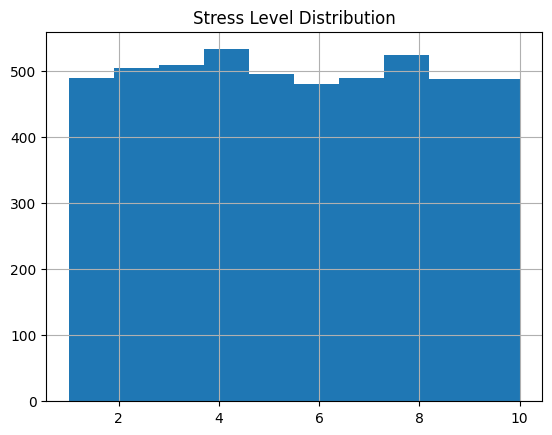

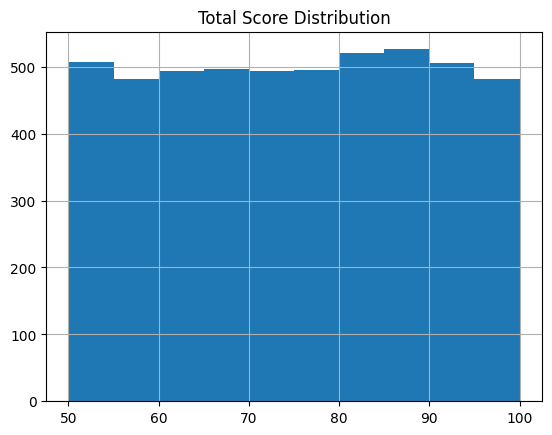

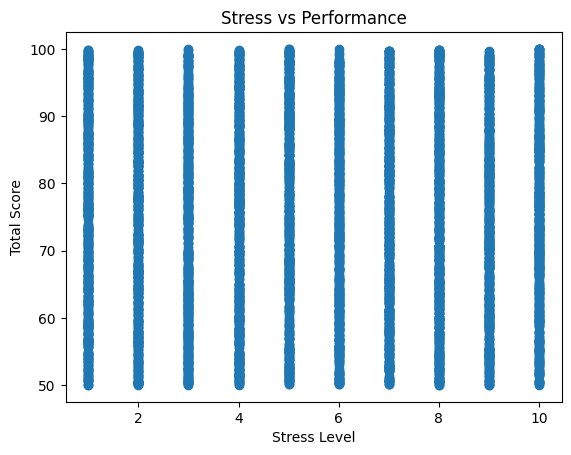

                     Stress_Level (1-10)  Total_Score
Stress_Level (1-10)             1.000000     0.004217
Total_Score                     0.004217     1.000000
Stress_Group
Low       74.861625
Medium    75.456985
High      75.063987
Name: Total_Score, dtype: float64


C:\Users\ROG\AppData\Local\Temp\ipykernel_30000\1166319977.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Stress_Group')['Total_Score'].mean())


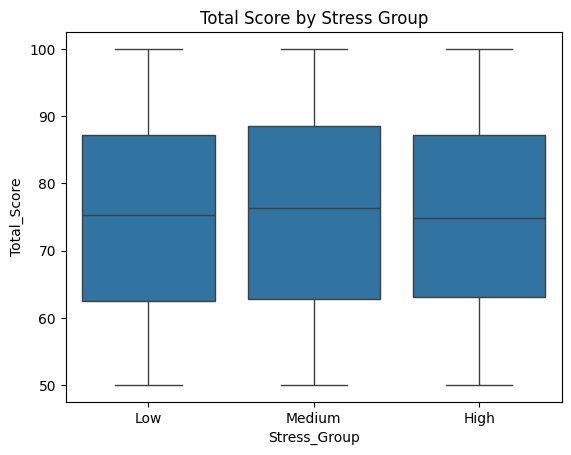

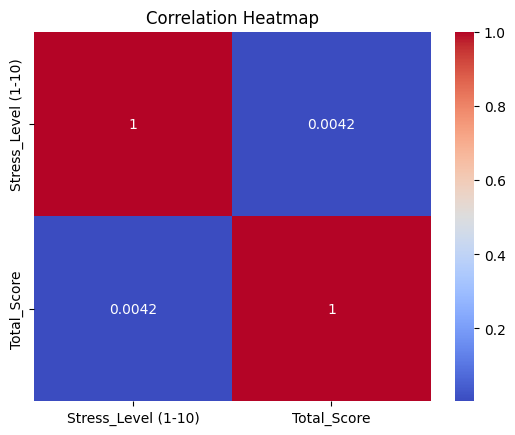

In [67]:
# Exercise 3
# EDA for column testing

# Inspect column basic
print(df['Stress_Level (1-10)'].describe())
print(df['Total_Score'].describe())

# Distribution analysis
df['Stress_Level (1-10)'].hist(bins=10)
plt.title('Stress Level Distribution')
plt.show()

df['Total_Score'].hist(bins=10)
plt.title('Total Score Distribution')
plt.show()

# Relation between stress and performance
plt.scatter(df['Stress_Level (1-10)'], df['Total_Score'])
plt.xlabel('Stress Level')
plt.ylabel('Total Score')
plt.title('Stress vs Performance')
plt.show()

print(df[['Stress_Level (1-10)', 'Total_Score']].corr())

# Group comparison
df['Stress_Group'] = pd.cut(df['Stress_Level (1-10)'], bins=[0, 3, 6, 10], labels=['Low', 'Medium', 'High'])
print(df.groupby('Stress_Group')['Total_Score'].mean())

# Visual insight
sns.boxplot(x='Stress_Group', y='Total_Score', data=df)
plt.title('Total Score by Stress Group')
plt.show()

sns.heatmap(df[['Stress_Level (1-10)', 'Total_Score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [69]:
# Exercise 4
# Descriptive statistics of testing column (count, mean, std)

# Define two groups based on stress level
high_stress = df[df['Stress_Level (1-10)'] >= 7]['Total_Score']
low_stress = df[df['Stress_Level (1-10)'] <= 4]['Total_Score']

# Descriptive statistics for high stress group
print("HIGH STRESS GROUP (Stress Level >= 7):")
print(f"Count: {high_stress.count()}")
print(f"Mean:  {high_stress.mean():.4f}")
print(f"Std:   {high_stress.std():.4f}")

print("\nLOW STRESS GROUP (Stress Level <= 4):")
print(f"Count: {low_stress.count()}")
print(f"Mean:  {low_stress.mean():.4f}")
print(f"Std:   {low_stress.std():.4f}")

# Summary table
summary_stats = pd.DataFrame({
    'High Stress': {'Count': high_stress.count(), 'Mean': high_stress.mean(), 'Std': high_stress.std()},
    'Low Stress': {'Count': low_stress.count(), 'Mean': low_stress.mean(), 'Std': low_stress.std()}
}).T
print("\n" + "="*50)
print(summary_stats)

HIGH STRESS GROUP (Stress Level >= 7):
Count: 1989
Mean:  75.0640
Std:   14.2513

LOW STRESS GROUP (Stress Level <= 4):
Count: 2035
Mean:  74.8365
Std:   14.4365

              Count       Mean        Std
High Stress  1989.0  75.063987  14.251261
Low Stress   2035.0  74.836482  14.436545


In [70]:
# Exercise 5
# Calculate T-Statistic and P-Value
# significance level is 0.05
# Does High Stress Lead to Lower Performance?
alpha = 0.05

# Two groups based on stress level
high_stress = df[df['Stress_Level (1-10)'] >= 7]['Total_Score']
low_stress  = df[df['Stress_Level (1-10)'] <= 4]['Total_Score']

# Independent t-test
t_stat, p_value = stats.ttest_ind(high_stress, low_stress)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
print(f"Alpha       : {alpha}")

if p_value < alpha:
    print("\nReject H₀ — High stress significantly lowers performance")
else:
    print("\nFail to reject H₀ — No significant difference")

T-Statistic : 0.5030
P-Value     : 0.6150
Alpha       : 0.05

Fail to reject H₀ — No significant difference


In [31]:
# Exercise 6
# Conclussion result 

